# 📊 Projeto de Análise de Vendas
##📌 Sobre este Notebook
### Esse notebook servirá para hospedar o código Python para limpeza e tratamento dos dados e para análise exploratória.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/sample_data/Sample_Superstore.csv', encoding='latin-1')

#Remoção de duplicatas e limpeza de nulos e outliers

In [ ]:
df = df.drop_duplicates()
df.isnull().sum()
def remover_outliers(df):
    numeric_columns = df.select_dtypes(include=['number']).columns

    df_clean = df.copy()
    for col in numeric_columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        inferior_limit = Q1 - 1.5 * IQR
        superior_limit = Q3 + 1.5 * IQR

        # Filtring the Data
        df_clean = df_clean[(df_clean[col] >= inferior_limit) & (df_clean[col] <= superior_limit)]

    return df_clean

df = remover_outliers(df)

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100

#Análise exploratória

In [ ]:
# Indicadores Globais
ticket_medio = df.groupby('Order ID')['Sales'].sum().mean()
receita_total = df['Sales'].sum()
lucro_total = df['Profit'].sum()

print(f"Receita Total: ${receita_total:,.2f}")
print(f"Lucro Total: ${lucro_total:,.2f}")
print(f"Ticket Médio por Pedido: ${ticket_medio:,.2f}")

# Resumo por Categoria
resumo_categoria = df.groupby('Category').agg(
    Receita=('Sales', 'sum'),
    Lucro=('Profit', 'sum'),
    Margem_Media=('Profit Margin %', 'mean'),
    Qtd_Pedidos=('Order ID', 'nunique')
).reset_index()

# Resumo por Região
resumo_regiao = df.groupby('Region').agg(
    Receita=('Sales', 'sum'),
    Lucro=('Profit', 'sum'),
    Margem_Media=('Profit Margin %', 'mean')
).sort_values(by='Lucro', ascending=False).reset_index()

display(resumo_categoria)
print(" ")
print(" ")
display(resumo_regiao)

Receita Total: $207,001.94
Lucro Total: $47,496.09
Ticket Médio por Pedido: $58.44


,Category,Receita,Lucro,Margem_Media,Qtd_Pedidos
0,Furniture,42867.879,7004.2752,23.399183,699
1,Office Supplies,114766.130,33720.8402,32.403461,2807
2,Technology,49367.932,6770.9772,14.541722,707


,Region,Receita,Lucro,Margem_Media
0,West,73270.624,17567.7759,30.167346
1,East,60265.794,14093.8917,28.693185
2,Central,40198.671,8387.7821,26.859264
3,South,33266.852,7446.6429,27.633484


### 💡 Insight de Negócio
#### Existe correlação entre desconto e lucro?

🔗 Correlação de Pearson (Desconto x Lucro): -0.2980


/tmp/ipykernel_848/1427247123.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Discount Band', y='Profit', ax=axes[0], palette='Blues_r', ci=None)
/tmp/ipykernel_848/1427247123.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Discount Band', y='Profit', ax=axes[0], palette='Blues_r', ci=None)


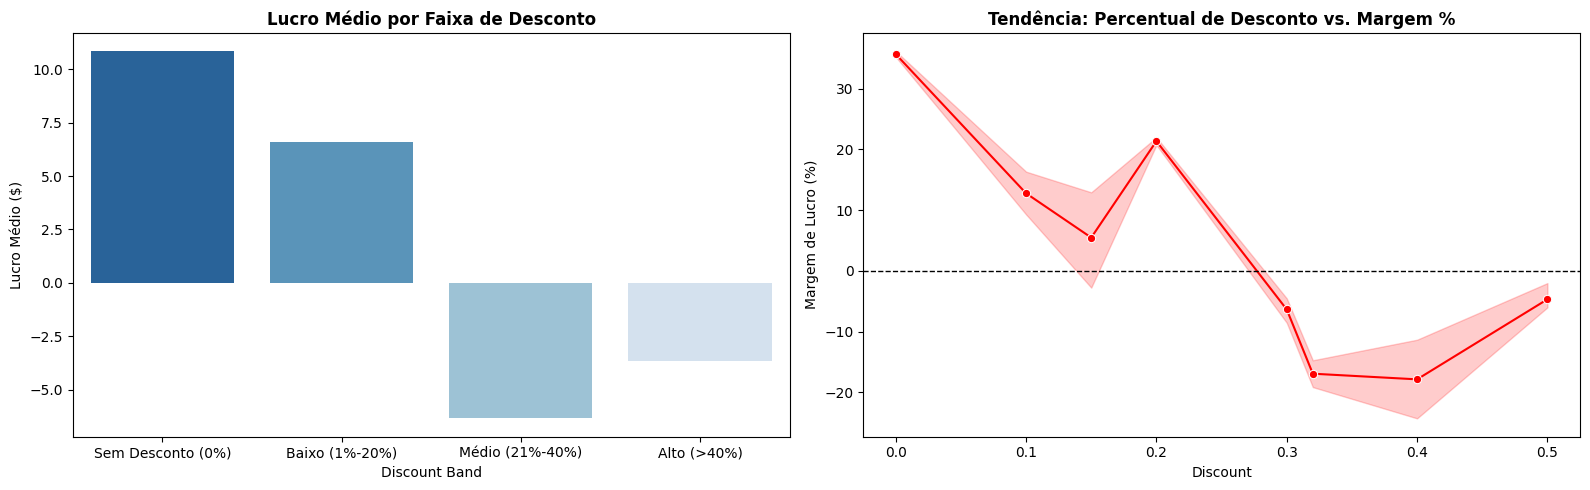

In [ ]:
# Criando faixas de desconto para análise pontual
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.0, 0.2, 0.4, 0.8],
    labels=['Sem Desconto (0%)', 'Baixo (1%-20%)', 'Médio (21%-40%)', 'Alto (>40%)']
)

# Correlação simples entre Desconto e Lucro
correlacao = df['Discount'].corr(df['Profit'])
print(f"🔗 Correlação de Pearson (Desconto x Lucro): {correlacao:.4f}")

# Gráfico de Lucro Médio e Margem por Faixa de Desconto
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df, x='Discount Band', y='Profit', ax=axes[0], palette='Blues_r', ci=None)
axes[0].set_title('Lucro Médio por Faixa de Desconto', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Lucro Médio ($)')

sns.lineplot(data=df, x='Discount', y='Profit Margin %', ax=axes[1], color='red', marker='o')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Tendência: Percentual de Desconto vs. Margem %', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Margem de Lucro (%)')

plt.tight_layout()
plt.show()

### 💡 Insight de Negócio
#### Sazonalidade impacta nas vendas ?
#### Qual categoria deu mais lucro?
#### Quais produtos com mais receita?

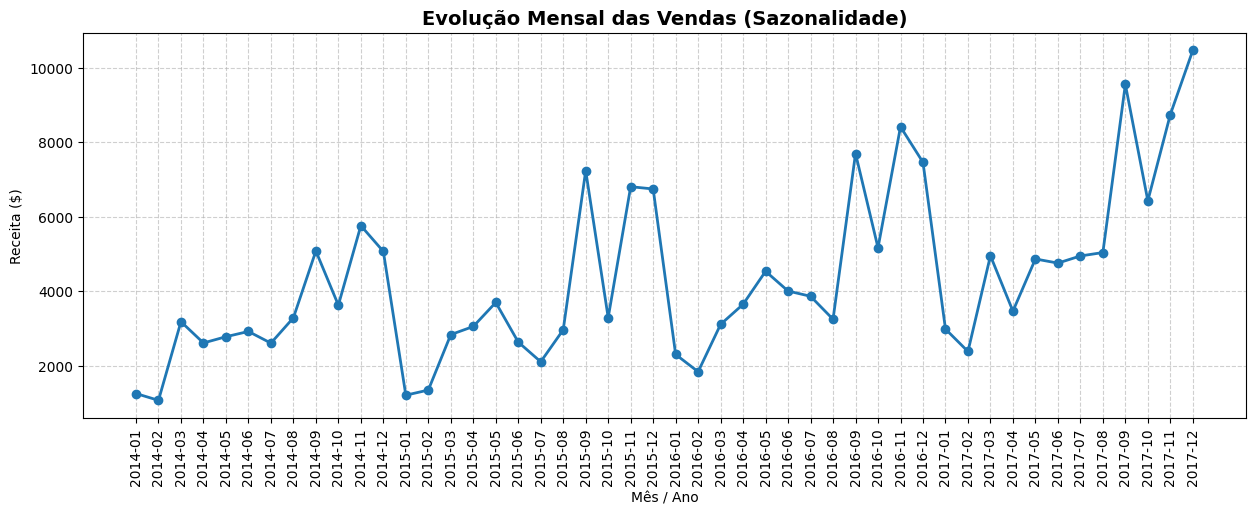

/tmp/ipykernel_848/1617965139.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_produtos, y='Product Name', x='Sales', palette='Blues_r')


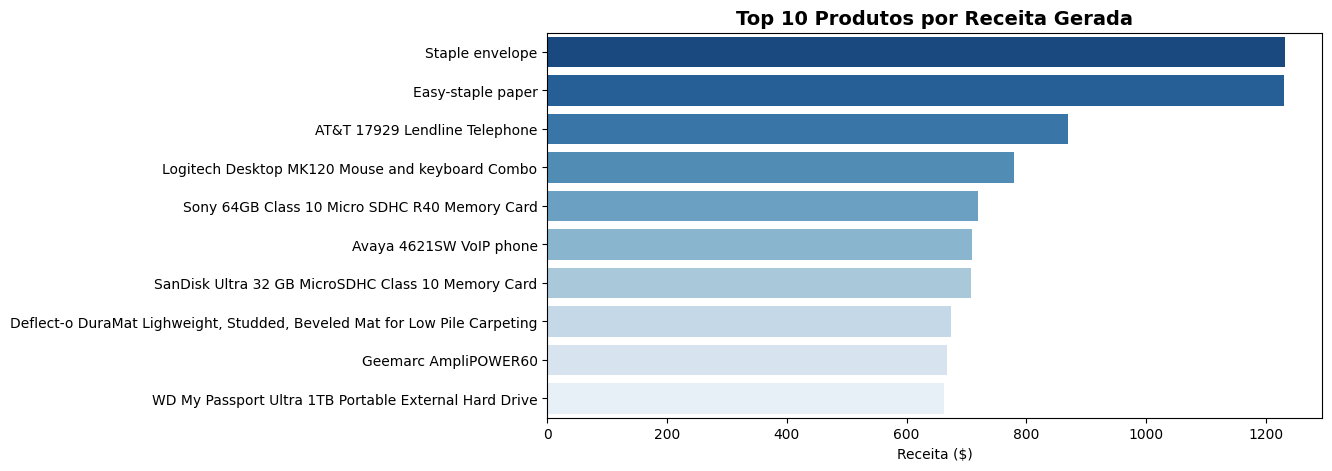

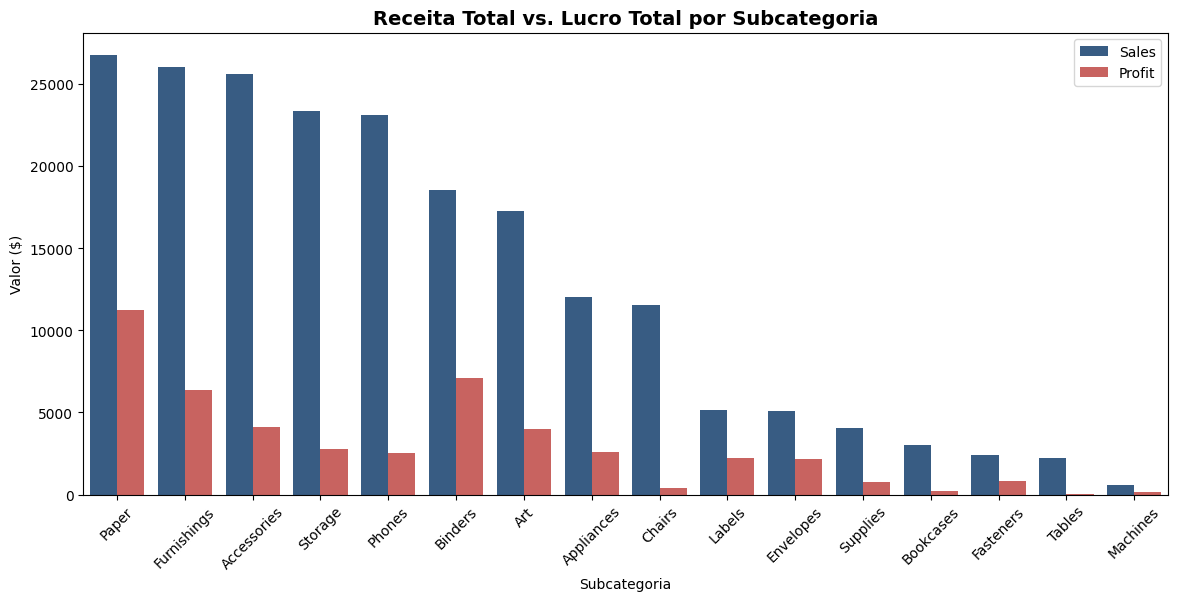

In [ ]:
# Sazonalidade de Vendas (Vendas Mensais ao longo do tempo)
df_vendas_mes = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
df_vendas_mes['Order Date'] = df_vendas_mes['Order Date'].astype(str)

plt.figure(figsize=(15, 5))
plt.plot(df_vendas_mes['Order Date'], df_vendas_mes['Sales'], marker='o', linewidth=2, color='#1f77b4')
plt.xticks(rotation=90)
plt.title('Evolução Mensal das Vendas (Sazonalidade)', fontsize=14, fontweight='bold')
plt.xlabel('Mês / Ano')
plt.ylabel('Receita ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Top 10 Produtos Mais Vendidos em Receita
top10_produtos = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_produtos, y='Product Name', x='Sales', palette='Blues_r')
plt.title('Top 10 Produtos por Receita Gerada', fontsize=14, fontweight='bold')
plt.xlabel('Receita ($)')
plt.ylabel('')
plt.show()

# Receita vs. Lucro por Sub-categoria (Comparativo Duplo)
df_subcat = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).reset_index()

df_subcat_melted = df_subcat.melt(id_vars='Sub-Category', value_vars=['Sales', 'Profit'],
                                  var_name='Métrica', value_name='Valor')

plt.figure(figsize=(14, 6))
sns.barplot(data=df_subcat_melted, x='Sub-Category', y='Valor', hue='Métrica', palette=['#2b5c8f', '#d9534f'])
plt.xticks(rotation=45)
plt.title('Receita Total vs. Lucro Total por Subcategoria', fontsize=14, fontweight='bold')
plt.xlabel('Subcategoria')
plt.ylabel('Valor ($)')
plt.legend(title='')
plt.show()

### 💡 Insight de Negócio
#### Gasto do cliente tem relação com fidelidade dele?

/tmp/ipykernel_848/3999571986.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y='Segmento', order=order_seg, palette='Set2')


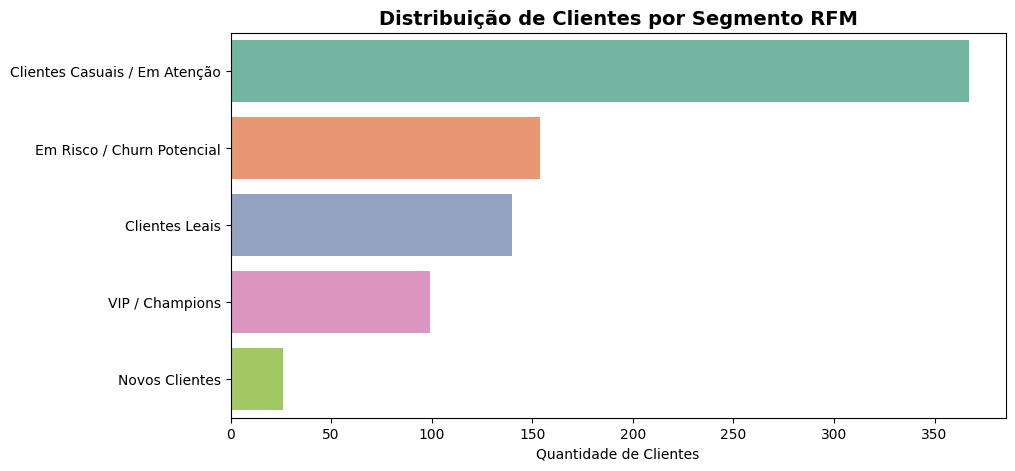


--- Resumo Financeiro por Segmento RFM ---


,Qtd_Clientes,Recencia_Media,Frequencia_Media,Gasto_Medio
Segmento,,,,
Clientes Casuais / Em Atenção,367,315.56,2.89,168.19
Clientes Leais,140,46.18,5.44,279.62
Em Risco / Churn Potencial,154,267.63,5.83,353.80
Novos Clientes,26,20.19,2.46,147.62
VIP / Champions,99,39.34,7.67,482.90


In [ ]:
# Definir data de referência (um dia após o último pedido registrado no dataset)
data_referencia = df['Order Date'].max() + pd.Timedelta(days=1)

# Cálculo das Métricas RFM por Cliente
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (data_referencia - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Criação dos Scores de 1 a 4 (usando quartis)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# Score RFM Combinado
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Mapeamento em Segmentos Práticos
def categorizar_rfm(df_rfm):
    if df_rfm['RFM_Score'] in ['444', '443', '344']:
        return 'VIP / Champions'
    elif df_rfm['F_Score'] in [3, 4] and df_rfm['R_Score'] in [3, 4]:
        return 'Clientes Leais'
    elif df_rfm['R_Score'] in [1, 2] and df_rfm['F_Score'] in [3, 4]:
        return 'Em Risco / Churn Potencial'
    elif df_rfm['R_Score'] == 4 and df_rfm['F_Score'] == 1:
        return 'Novos Clientes'
    else:
        return 'Clientes Casuais / Em Atenção'

rfm['Segmento'] = rfm.apply(categorizar_rfm, axis=1)

# Visualização da Distribuição dos Segmentos RFM
plt.figure(figsize=(10, 5))
order_seg = rfm['Segmento'].value_counts().index
sns.countplot(data=rfm, y='Segmento', order=order_seg, palette='Set2')
plt.title('Distribuição de Clientes por Segmento RFM', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Clientes')
plt.ylabel('')
plt.show()

print("\n--- Resumo Financeiro por Segmento RFM ---")
display(rfm.groupby('Segmento').agg(
    Qtd_Clientes=('Customer ID', 'count'),
    Recencia_Media=('Recency', 'mean'),
    Frequencia_Media=('Frequency', 'mean'),
    Gasto_Medio=('Monetary', 'mean')
).round(2))

### 💡 Insight de Negócio
#### Tempo das entregas é afetado pelo tipo categoria de envio ?


/tmp/ipykernel_848/3950679361.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Ship Mode', y='Shipping Days', palette='Pastel1')


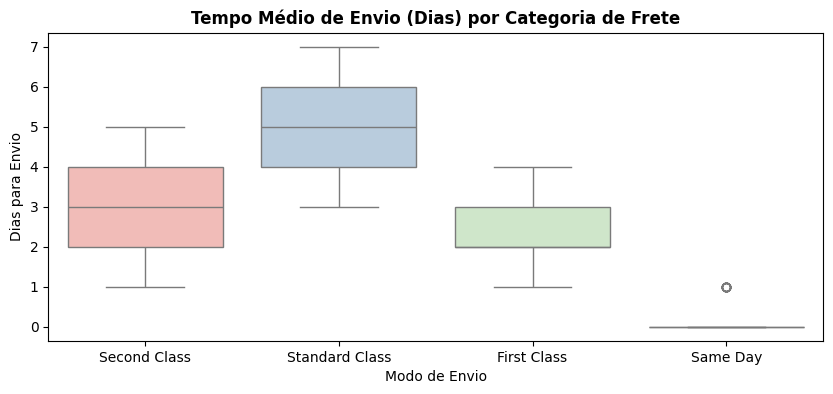

In [ ]:
#Eficiência Logística (Tempo de envio por categoria)
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Ship Mode', y='Shipping Days', palette='Pastel1')
plt.title('Tempo Médio de Envio (Dias) por Categoria de Frete', fontsize=12, fontweight='bold')
plt.xlabel('Modo de Envio')
plt.ylabel('Dias para Envio')
plt.show()